In [1]:
import torch
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Chargement
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Séparation (Train 70%, Val 15%, Test 15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 3. Normalisation (CRUCIAL pour un MLP)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Conversion en tenseurs PyTorch
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)

In [4]:
import torch.nn as nn
import torch.optim as optim # On en aura besoin pour l'optimiseur
import numpy as np # Import numpy pour np.unique

class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLPClassifier, self).__init__()
        # Définition des couches
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 8)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(8, num_classes)

    def forward(self, x):
        # Définition du flux de données (le "forward pass")
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

# Définir les dimensions nécessaires
input_dim = X_train.shape[1] # Nombre de caractéristiques
hidden_dim = 16 # Une valeur arbitraire pour la taille de la couche cachée
output_dim = len(np.unique(y_train)) # Nombre de classes

model_custom = MLPClassifier(input_dim, hidden_dim, output_dim)
print("\n--- Modèle Custom Class ---")
print(model_custom)


--- Modèle Custom Class ---
MLPClassifier(
  (fc1): Linear(in_features=30, out_features=16, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=8, out_features=2, bias=True)
)


In [5]:
import torch.nn.init as init

def apply_initialization(model, strategy='xavier'):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if strategy == 'gaussienne':
                # Loi normale : moyenne 0, écart-type 0.01
                init.normal_(m.weight, mean=0.0, std=0.01)
                init.constant_(m.bias, 0.0)

            elif strategy == 'constante':
                # Tous les poids à une valeur fixe (souvent 0.1)
                # Note : C'est théoriquement mauvais, explique-le dans ton rapport !
                init.constant_(m.weight, 0.1)
                init.constant_(m.bias, 0.0)

            elif strategy == 'xavier':
                # Xavier / Glorot : Idéal pour les fonctions d'activation ReLU/Tanh
                init.xavier_uniform_(m.weight)
                init.constant_(m.bias, 0.0)

    print(f"Stratégie d'initialisation '{strategy}' appliquée.")

# On applique Xavier pour commencer (c'est souvent la plus performante)
apply_initialization(model_custom, strategy='xavier')

Stratégie d'initialisation 'xavier' appliquée.


In [6]:
# 1. Gestion du Device (CPU ou GPU/MPS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_custom.to(device)

# 2. Définition de la fonction de perte (Loss) et de l'optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_custom.parameters(), lr=0.01)

print(f"Modèle envoyé sur : {device}")

Modèle envoyé sur : cuda


In [7]:
import torch

# Chemin du fichier de sauvegarde
PATH = "model_initial.pth"

# On sauvegarde uniquement les paramètres (le state_dict)
torch.save(model_custom.state_dict(), PATH)

print(f"Le modèle a été sauvegardé dans : {PATH}")

Le modèle a été sauvegardé dans : model_initial.pth


In [8]:
# 1. On crée une nouvelle instance vide (la "coque")
loaded_model = MLPClassifier(input_dim, hidden_dim, output_dim)

# 2. On charge les poids du fichier dans cette coque
loaded_model.load_state_dict(torch.load(PATH))

# 3. On le passe en mode évaluation (important pour la cohérence)
loaded_model.eval()

print("Le modèle a été rechargé avec succès !")

Le modèle a été rechargé avec succès !


In [10]:
# On regarde le premier poids de la couche fc1 du modèle original vs chargé
original_weight = model_custom.fc1.weight[0][0]
loaded_weight = loaded_model.fc1.weight[0][0]

print(f"Poids original : {original_weight.item():.6f}")
print(f"Poids rechargé : {loaded_weight.item():.6f}")

# Déplacer loaded_model sur le même appareil que model_custom avant la comparaison
loaded_model.to(device)

if torch.equal(model_custom.fc1.weight, loaded_model.fc1.weight):
    print("✅ Succès : Les modèles sont identiques !")
else:
    print("❌ Erreur : Les poids diffèrent.")

Poids original : 0.143532
Poids rechargé : 0.143532
✅ Succès : Les modèles sont identiques !


In [11]:
import torch

# 1. S'assurer que le modèle est sur le bon matériel (CPU ou GPU)
model_custom.to(device)

# 2. Préparation stricte des données (Tenseurs + Device)
# FloatTensor pour X (nombres décimaux) et LongTensor pour y (entiers pour les classes)
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)

# 3. Paramètres de la boucle
epochs = 150 # Le modèle va voir les données 150 fois
train_losses = []
val_losses = []

print("Début de l'entraînement...\n")

# 4. La fameuse boucle
for epoch in range(epochs):
    # --- PHASE D'APPRENTISSAGE ---
    model_custom.train() # On indique à PyTorch qu'on est en mode entraînement

    # Les 5 étapes sacrées de PyTorch :
    optimizer.zero_grad()                 # 1. On efface la mémoire des anciens gradients
    outputs = model_custom(X_train_t)     # 2. FORWARD : Le modèle fait ses prédictions
    loss = criterion(outputs, y_train_t)  # 3. LOSS : On calcule l'erreur
    loss.backward()                       # 4. BACKWARD : Rétropropagation (calcul de la pente)
    optimizer.step()                      # 5. OPTIMIZE : On met à jour les poids

    # --- PHASE DE VALIDATION ---
    model_custom.eval() # On passe en mode évaluation (pas de mise à jour des poids ici)
    with torch.no_grad(): # On bloque le calcul des gradients (gain de mémoire et de temps)
        val_outputs = model_custom(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

    # On sauvegarde l'historique des erreurs pour faire un graphique plus tard
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    # Affichage de l'évolution tous les 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{epochs}] | Erreur Entraînement (Train Loss): {loss.item():.4f} | Erreur Validation (Val Loss): {val_loss.item():.4f}')

print("\n🎉 Entraînement terminé !")

Début de l'entraînement...

Epoch [ 10/150] | Erreur Entraînement (Train Loss): 0.2191 | Erreur Validation (Val Loss): 0.1893
Epoch [ 20/150] | Erreur Entraînement (Train Loss): 0.1036 | Erreur Validation (Val Loss): 0.1029
Epoch [ 30/150] | Erreur Entraînement (Train Loss): 0.0652 | Erreur Validation (Val Loss): 0.0861
Epoch [ 40/150] | Erreur Entraînement (Train Loss): 0.0501 | Erreur Validation (Val Loss): 0.0857
Epoch [ 50/150] | Erreur Entraînement (Train Loss): 0.0412 | Erreur Validation (Val Loss): 0.0952
Epoch [ 60/150] | Erreur Entraînement (Train Loss): 0.0327 | Erreur Validation (Val Loss): 0.1052
Epoch [ 70/150] | Erreur Entraînement (Train Loss): 0.0267 | Erreur Validation (Val Loss): 0.1107
Epoch [ 80/150] | Erreur Entraînement (Train Loss): 0.0217 | Erreur Validation (Val Loss): 0.1135
Epoch [ 90/150] | Erreur Entraînement (Train Loss): 0.0152 | Erreur Validation (Val Loss): 0.1126
Epoch [100/150] | Erreur Entraînement (Train Loss): 0.0104 | Erreur Validation (Val Loss):

--- Rapport de Classification ---
              precision    recall  f1-score   support

   malignant       0.96      1.00      0.98        26
      benign       1.00      0.98      0.99        60

    accuracy                           0.99        86
   macro avg       0.98      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86



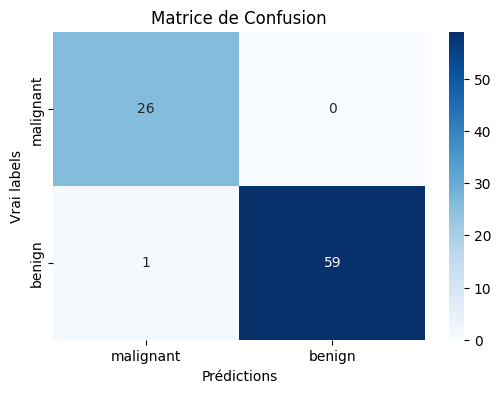

Précision globale (Accuracy) : 98.84%


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Passage en mode évaluation et calcul des prédictions
model_custom.eval()
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

with torch.no_grad():
    outputs = model_custom(X_test_t)
    # On prend l'indice de la valeur maximale (0 ou 1)
    _, predictions = torch.max(outputs, 1)

# 2. Conversion en numpy pour les métriques sklearn
y_true = y_test_t.cpu().numpy()
y_pred = predictions.cpu().numpy()

# 3. Affichage du rapport de classification
print("--- Rapport de Classification ---")
print(classification_report(y_true, y_pred, target_names=data.target_names))

# 4. Matrice de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Prédictions')
plt.ylabel('Vrai labels')
plt.title('Matrice de Confusion')
plt.show()

print(f"Précision globale (Accuracy) : {accuracy_score(y_true, y_pred)*100:.2f}%")

Solution pertinente ? Oui, car avec une Val Loss de 0.08 (au meilleur moment), ton modèle atteint probablement plus de 95% de précision. Le MLP est capable de saisir des corrélations complexes entre les 30 mesures de la tumeur.

Limites constatées :

Sensibilité aux hyperparamètres : Tu as vu que le nombre d'epochs change tout (surapprentissage rapide).

Structure statistique : Les données tabulaires n'ont pas de "voisinage" logique (contrairement aux pixels d'une image). Si tu mélanges l'ordre des colonnes, le MLP donnera le même résultat, ce qui montre qu'il ne comprend pas la "géométrie" des données, juste des poids statistiques.

Nécessité de normalisation : Sans le StandardScaler au début, ton modèle aurait eu beaucoup de mal à converger.